In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [43]:
t = 1
X, Y = 60, 60
lattice = Lattice(X, Y, pbc_x=False)

mu = 1.8 * t * np.ones(lattice.X)
T = 0.01

V0 = 1.5 * t / 2
V = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [44]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-5, rtol=1e-3,
                                      maxiter=1000, verbose=True, 
                                      temperature=T)

F0:
Absolute error: 9.454501515152614e-16
Relative error: 0.0009454501515152612
Average old: 0j
Average: (-4.040738038512405e-18+0j)
F_xplus:
Absolute error: 0.20408107661140554
Relative error: 2.0408107660936468
Average old: (0.09999999999999999+0j)
Average: (0.07459870685719977+0j)
F_xmin:
Absolute error: 0.20408107661140565
Relative error: 2.0408107661344643
Average old: (-0.09999999999999999+0j)
Average: (-0.07459870685719977+0j)
F_yplus:
Absolute error: 0.15937006546217103
Relative error: 1.5937006546217103
Average old: 0.10000000000000002j
Average: (2.3961958488313918e-17+0.0796459306012209j)
F_ymin:
Absolute error: 0.15937006546217103
Relative error: 1.5937006546217103
Average old: -0.10000000000000002j
Average: (2.3961958488313918e-17-0.0796459306012209j)
Fuu_xplus:
Absolute error: 1.219966365930778e-16
Relative error: 0.0001219966365930778
Average old: 0j
Average: (1.0397271398120503e-17+0j)
Fuu_xmin:
Absolute error: 1.165245635567176e-16
Relative error: 0.0001165245635567176


In [45]:
F, Fuu, Fdd = H.get_correlations()

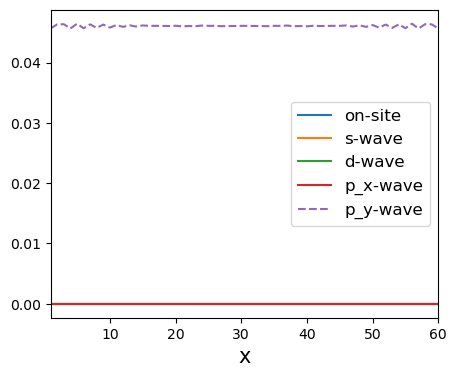

In [46]:
x = np.arange(1, X + 1)

fig, axs = plt.subplots(1, 1, figsize=(5, 4))

axs.plot(x, np.abs(H.F0), label="on-site")
axs.plot(x, np.abs(F_swave), label="s-wave")
axs.plot(x, np.abs(F_dwave), label="d-wave")
axs.plot(x, np.abs(F_px), label="p_x-wave")
axs.plot(x, np.abs(F_py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(1, X)
axs.legend(fontsize=12, loc="best")

plt.show()

In [47]:
print(F.px[X//2])
print(F.py[X//2])

(2.310936710382331e-13+0j)
0.04609929073900903j


In [2]:
X, Y = 10, 200
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0.001

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [14]:
bdg_sc(H, rtol=0.01, maxiter=200, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()
F0 = H.F0

F0:
Absolute error: 1.4452068629904467e-16
Relative error: 0.00014419052508488257
Average old: (2.609967816802693e-15+0j)
Average: (2.6003178345169986e-15+0j)
F_xplus:
Absolute error: 3.7566871938073975e-05
Relative error: 0.004683173381693015
Average old: (0.0077490022491862745+0j)
Average: (0.007736906596339015+0j)
F_xmin:
Absolute error: 3.756687193814214e-05
Relative error: 0.0046831733830272615
Average old: (-0.007749002249181808+0j)
Average: (-0.007736906596334523+0j)
F_yplus:
Absolute error: 7.530156727477918e-07
Relative error: 3.172360901565373e-06
Average old: (-5.6791787856202714e-15+0.2403401945184241j)
Average: (-5.686534679356442e-15+0.24034037143928538j)
F_ymin:
Absolute error: 7.530156727477918e-07
Relative error: 3.172360901565373e-06
Average old: (-5.6791787856202714e-15-0.2403401945184241j)
Average: (-5.686534679356442e-15-0.24034037143928538j)
Fuu_xplus:
Absolute error: 1.2996299691597113e-17
Relative error: 1.299631374989275e-05
Average old: (4.31893168092532e-19+0

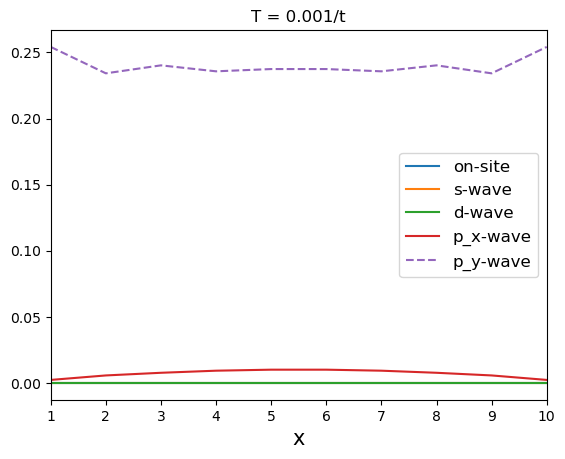

In [13]:
x = np.arange(1, X + 1)
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F.swave), label="s-wave")
plt.plot(x, np.real(F.dwave), label="d-wave")
plt.plot(x, np.real(F.px), label="p_x-wave")
plt.plot(x, np.imag(F.py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

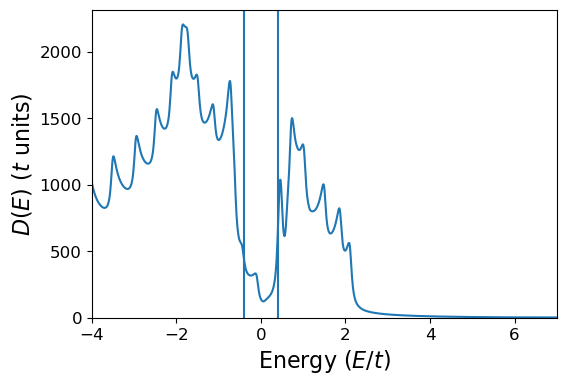

In [12]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.axvline(-0.2 * 2)
plt.axvline(+0.2 * 2)

# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
free1 = H.free
free2 = H.free_energy()

print(free1)
print(free2)

-127.9454734630715
51.896447155617075


In [ ]:
X, Y = 10, 20
lattice = Lattice(X, Y, pbc_x=False)

t = 1
mu = 0.1 * t * np.ones(lattice.X)
T = 0.01

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1 , -0.1])

In [ ]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000,
                                      verbose=True, temperature=T)

F0:
Absolute error: 0.0350670973473647
Relative error: 35067097347.3647
Average old: 0j
Average: (0.010836119327615372+0j)
F_xplus:
Absolute error: 0.35382013729419376
Relative error: 3.538201372906555
Average old: (0.09999999999999999+0j)
Average: (0.2169773071218056+0j)
F_xmin:
Absolute error: 0.3538201372941936
Relative error: 3.5382013729065536
Average old: (0.09999999999999999+0j)
Average: (0.21697730712180557+0j)
F_yplus:
Absolute error: 0.3449467215220631
Relative error: 3.449467215255126
Average old: (-0.1+0j)
Average: (-0.2075748136941079+8.166210763160823e-18j)
F_ymin:
Absolute error: 0.3449467215220631
Relative error: 3.449467215255126
Average old: (-0.1+0j)
Average: (-0.2075748136941079-8.166210763160823e-18j)
Fuu_xplus:
Absolute error: 3.278090502108133e-17
Relative error: 3.278090502108133e-05
Average old: 0j
Average: (-4.589583601310682e-18+0j)
Fuu_xmin:
Absolute error: 4.417862705508784e-17
Relative error: 4.417862705508784e-05
Average old: 0j
Average: (7.76372990503119

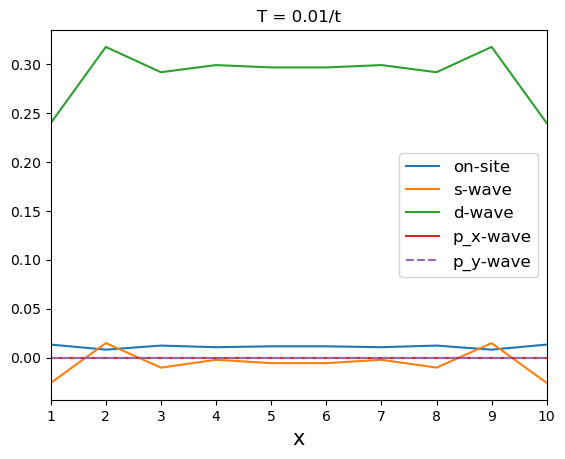

In [ ]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

In [ ]:
import numpy as np
temps = np.concatenate([
    np.arange(0.001, 0.020 + 1e-12, 0.001),
    np.arange(0.021, 0.040 + 1e-12, 0.0002),
    np.arange(0.041, 0.061 + 1e-12, 0.0002),
    np.arange(0.062, 0.080 + 1e-12, 0.0005),
    np.arange(0.081, 0.100 + 1e-12, 0.002)
])
len(temps)

264

In [ ]:
X, Y = 25, 50
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 0.9 * t * np.ones(lattice.X)
T = 0.1

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t /2 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1+0.1, -0.1-0.1])

In [ ]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=100, atol =1e-4,
                                      verbose=True, temperature=T)

F0:
Absolute error: 0.09795092384137324
Relative error: 97950923841.37323
Average old: 0j
Average: (0.013454743464616043+2.2371687835587304e-17j)
F_xplus:
Absolute error: 0.4039215769637653
Relative error: 4.03921576959726
Average old: (0.09999999999999999+0j)
Average: (0.1819809842790503-3.8900609260148384e-18j)
F_xmin:
Absolute error: 0.40392157696376496
Relative error: 4.039215769597257
Average old: (0.09999999999999999+0j)
Average: (0.1819809842790502-1.3529826673082383e-17j)
F_yplus:
Absolute error: 0.0916848653632356
Relative error: 91684865363.23561
Average old: 0j
Average: (-0.01622306163966027+8.21755857804972e-18j)
F_ymin:
Absolute error: 0.7689442467516842
Relative error: 3.8447212337776437
Average old: (-0.2+0j)
Average: (-0.3536673503442182-1.3919681379759307e-17j)
Fuu_xplus:
Absolute error: 9.445872620229822e-17
Relative error: 9.44587262022982e-05
Average old: 0j
Average: (-1.4771829208286692e-22+1.4641877278438024e-17j)
Fuu_xmin:
Absolute error: 1.0095685945545078e-16
R

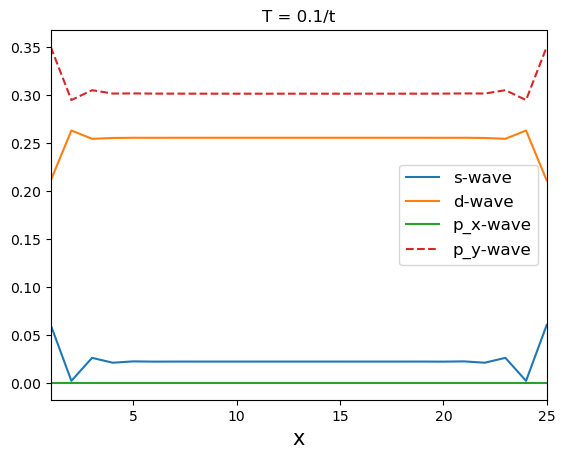

In [ ]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
# plt.plot(x, np.abs(F0), label="on-site")
plt.plot(x, np.abs(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.real(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")